# Assignment 13 Text Analytics

In this assignment, you will:
- Load and inspect a real-world business reviews dataset.
- Preprocess review text for NLP (tokenization, stopwords, lemmatization).
- Run sentiment analysis (rule-based and classifier-based) and compare to star ratings.
- Extract main topics from reviews using LDA and (optional) BERTopic.
- Interpret results in a business context (actionable insights).

## Why This Matters

Customer Reviews are critical for the survival of any business, but especially for restaurants.  Restaurants compete with not only all of the other restaurants in local area, but also with the option for customers to stay home and cook their own food.  Chefs and restaurant owners must monitor customer feedback to see if they should make changes to their pricing, menu options, restaurant amenities and seating/serving process.

You have been given 100 customer reviews.  Your job is to look for main topics that are mentioned, and whether those reviews have a postive, neutral or negative tone (sentiment).  

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_13_text_analytics.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Original Source: Dataset Description

The dataset you'll be using is a set of **restaurant reviews**, available from [Kaggle](https://www.kaggle.com/datasets/pruthvirajgshitole/e-commerce-purchases-and-reviews?utm_source=chatgpt.com&select=customer_purchase_data.csv).

Each row represents one customer review. The columns include:

- **Review** - text of the customer review
- **Liked** - indicates if the customer likes (1) or does not like (0) the restaurant

Please note that some reviews have commas and apostrophes, which can prevent the record from loading correctly.  You should verify that you have 1,000 reviews total.  

## 1. Load and Preview the Data

### Do the following:
1. Import data from the restaurant reviews dataset into a dataframe (in GitHub go to the DataSets folder and look for `Restaurant_Reviews.tsv`).  TSV is for Tab Separated Values.  This file does not use commas as a delimiter.
2. Use `pandas` to load and preview the dataset
3. Verify that all 1,000 rows were imported correctly
4. Calculate the overall percentage of reviews that "Liked" the restaurant
5. Create a visualization to show the percentage of likes versus non-likes


In [3]:
import pandas as pd
import csv

# Load the reviews
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/Restaurant_Reviews.tsv"
df = pd.read_csv(url, sep='\t', quoting=csv.QUOTE_MINIMAL)

df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


Number of rows imported: 1000
Percentage of reviews that 'Liked' the restaurant: 50.00%


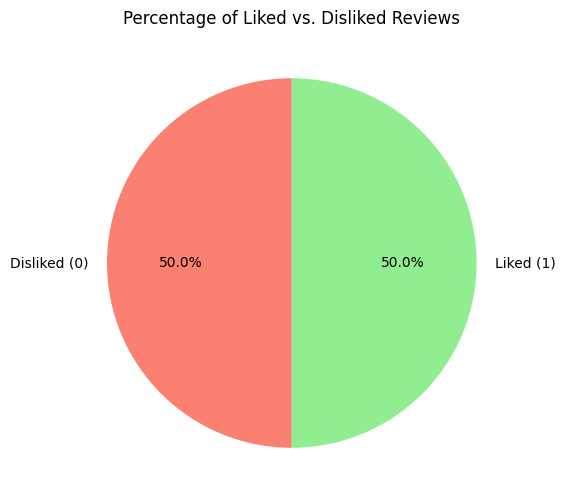

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Verify that all 1,000 rows were imported correctly
num_rows = df.shape[0]
print(f"Number of rows imported: {num_rows}")

# 4. Calculate the overall percentage of reviews that "Liked" the restaurant
liked_counts = df['Liked'].value_counts(normalize=True) * 100
liked_percentage = liked_counts.loc[1] if 1 in liked_counts.index else 0
print(f"Percentage of reviews that 'Liked' the restaurant: {liked_percentage:.2f}%")

# 5. Create a visualization to show the percentage of likes versus non-likes
plt.figure(figsize=(6, 6))
plt.pie(liked_counts, labels=['Disliked (0)', 'Liked (1)'], autopct='%1.1f%%', startangle=90, colors=['salmon', 'lightgreen'])
plt.title('Percentage of Liked vs. Disliked Reviews')
plt.show()

## 2. Drop Columns Not Useful for Modeling

**Business framing:**  
To do text analysis, we need to remove all of the junk in the reviews.  This would include anything like punctuation, website URLs, emojis, etc.

### Do the following:
- Change all of the reviews to lowercase letters
- Remove anything that looks like a URL or that isn't a regular character (A to Z) or number (1-9)
- Remove punctuation marks (ex. !.,-:;)

### In Your Response:
1. What risks might occur if you included the review "junk" in your model?


In [5]:
import re

def preprocess_text(text):
    # 1. Change all reviews to lowercase
    text = text.lower()

    # 2. Remove anything that looks like a URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Remove non-alphanumeric characters (keeping spaces)
    # This pattern keeps letters, numbers, and spaces.
    text = re.sub(r'[^a-z0-9\s]', '', text)

    # 4. Remove punctuation marks (already largely covered by the above, but as a specific step)
    text = re.sub(r'[\.,!\?:;]', '', text) # Removes common punctuation if any still exists

    return text

# Apply the preprocessing function to the 'Review' column
df['cleaned_review'] = df['Review'].apply(preprocess_text)

# Display the first few rows with the new cleaned_review column to verify
display(df[['Review', 'cleaned_review']].head())

,Review,cleaned_review
0,Wow... Loved this place.,wow loved this place
1,Crust is not good.,crust is not good
2,Not tasty and the texture was just nasty.,not tasty and the texture was just nasty
3,Stopped by during the late May bank holiday of...,stopped by during the late may bank holiday of...
4,The selection on the menu was great and so wer...,the selection on the menu was great and so wer...


### ✍️ Your Response: 🔧
1. If we include the word 'junk', the model will express severely and put all sentences include 'junk' to the specific emotions, althougth the real sentence's emotions were not.

## 3. Sentiment Analysis

**Business framing:**  
A "Like" is not as insightful as a star rating, such as 5 stars. It only has two values. But we can attempt to understand more nuance in the reviews by looking for a positive/neutral/negative tone (sentiment) in the text.   Then we can compare that to the "Likes" to see if they match.  

### Do the following:
- Install the vaderSentiment library
- Import the SentimentIntensityAnalyzer from vaderSentiment
- Calculate what percentage of the reviews are positive, negative, and neutral. The total percentages should add up to 100%

### In Your Response:
1. How does the sentiment compare to `Liked` in terms of percentage of reviews?
2. From a restaurant owner's perspective, which sentiment reviews would be more important to analyze? (positive, negative or neutral)


In [6]:
# Install vaderSentiment library
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.6 MB/s eta 0:00:00


In [7]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize VADER sentiment intensity analyzer
analyzer = SentimentIntensityAnalyzer()

# Function to get sentiment scores
def get_sentiment_score(text):
    vs = analyzer.polarity_scores(text)
    return vs['compound'] # We use the compound score for overall sentiment

# Apply sentiment analysis to the cleaned reviews
df['sentiment_score'] = df['cleaned_review'].apply(get_sentiment_score)

# Function to categorize sentiment
def categorize_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_category'] = df['sentiment_score'].apply(categorize_sentiment)

# Display the first few rows with sentiment scores and categories
display(df[['Review', 'cleaned_review', 'sentiment_score', 'sentiment_category']].head())

,Review,cleaned_review,sentiment_score,sentiment_category
0,Wow... Loved this place.,wow loved this place,0.8271,Positive
1,Crust is not good.,crust is not good,-0.3412,Negative
2,Not tasty and the texture was just nasty.,not tasty and the texture was just nasty,-0.5574,Negative
3,Stopped by during the late May bank holiday of...,stopped by during the late may bank holiday of...,0.6908,Positive
4,The selection on the menu was great and so wer...,the selection on the menu was great and so wer...,0.6249,Positive


In [8]:
# Calculate what percentage of the reviews are positive, negative, and neutral
sentiment_counts = df['sentiment_category'].value_counts(normalize=True) * 100

print("Sentiment Distribution:")
for sentiment, percentage in sentiment_counts.items():
    print(f"- {sentiment}: {percentage:.2f}%")

# Verify that the total percentages add up to 100%
print(f"Total Percentage: {sentiment_counts.sum():.2f}%")

Sentiment Distribution:
- Positive: 50.60%
- Negative: 25.50%
- Neutral: 23.90%
Total Percentage: 100.00%


In [ ]:
# Add code here 🔧

### ✍️ Your Response: 🔧
1. 'Liked' has difference against sentiment sentiment has three sections to divide, 'positive','neutral',and 'negative', while 'Liked' are divided in 'Like' or 'dislike'. Since sentiment has 'neutral', so the result would be difference.

2. For the owner's perspective, owner should focus on ;negative' section. There would be the revealed problem which is the cause of negative review. It would help for the restaurant the cause for changing the strategy.

## 4. Topic Analysis - Text Preprocessing

**Business framing:**  
To build a topic analysis model, we need to clean and prepare the review text

### Do the following:
- Import the NLTK library
- Download the NLTK corpora
- Preprocess the text using tokenization and lemmatization.  Be sure to remove any stopwords along the way.
- Display the first 10 processed reviews

### In Your Response:
1. What is a corpora and how is it used for text analysis?
2. What would be the tokens in the first review? "Wow... Loved this place."
3. What does lemmatization do?  How will it help in this process?


In [4]:
import pandas as pd
import csv
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# --- Start of code from previous cells to ensure 'df' and 'cleaned_review' are defined ---
# Load the reviews (from cell 3pSdBQsfIqjM)
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/Restaurant_Reviews.tsv"
df = pd.read_csv(url, sep='\t', quoting=csv.QUOTE_MINIMAL)

def preprocess_text(text):
    # 1. Change all reviews to lowercase
    text = text.lower()
    # 2. Remove anything that looks like a URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # 3. Remove non-alphanumeric characters (keeping spaces)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    # 4. Remove punctuation marks
    text = re.sub(r'[\.,!\?:;]', '', text)
    return text

# Apply the preprocessing function to the 'Review' column (from cell EuvVcRmeIqjO)
df['cleaned_review'] = df['Review'].apply(preprocess_text)
# --- End of code from previous cells ---

# Download necessary NLTK data (if not already downloaded)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def process_for_lda(text):
    # Tokenization
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    processed_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(processed_tokens)

# Apply the processing function to the cleaned reviews
df['processed_review'] = df['cleaned_review'].apply(process_for_lda)

# Display the first 10 processed reviews
print("First 10 Processed Reviews:")
for i, review in enumerate(df['processed_review'].head(10)):
    print(f"{i+1}. {review}")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


First 10 Processed Reviews:
1. wow loved place
2. crust good
3. tasty texture nasty
4. stopped late may bank holiday rick steve recommendation loved
5. selection menu great price
6. getting angry want damn pho
7. honeslty didnt taste fresh
8. potato like rubber could tell made ahead time kept warmer
9. fry great
10. great touch


### ✍️ Your Response: 🔧
1. Corpora is the large collection of text data used for language analysis. It helps the model understand words, sentence patterns, stopwords, and word meanings.

2. It works like 'Wow', 'loved', 'this', 'place'. If there are words in '...', it would be tokenization.

3. Lemmetization is used for changing words to the base form. For example, if the tokenized word is 'loves', it changes to 'love'.

## 5. Topic Analysis - Dictionary and Corpus

**Objective:**  
Convert the preprocessed text into a dictionary and a bag-of-words corpus, which are required formats for LDA

### Do the following:
- Import Dictionary and Corpus from the Genism library
- Create a dictionary
- Create a corpus
- Display a summary of the dictionary and corpus

### In Your Response:
1. What is a corpus and how is it useful?
2. How is a dictionary different from a corpus?

In [9]:
!pip install gensim
from gensim.corpora import Dictionary

# Tokenize the processed reviews
# The 'processed_review' column currently holds space-separated words, so split them into lists of tokens
tokenized_reviews = [doc.split() for doc in df['processed_review']]

# Create a dictionary from the tokenized reviews
dictionary = Dictionary(tokenized_reviews)

# Filter out words that appear in less than 5 documents (no_below)
# or in more than 50% of the documents (no_above), and keep only the top 100000 most frequent words
dictionary.filter_extremes(no_below=5, no_above=0.5, keep_n=100000)

# Display a summary of the dictionary
print(f"Number of unique tokens in the dictionary: {len(dictionary)}")
print("Sample of dictionary IDs and words (first 10):")
for i, (key, value) in enumerate(dictionary.items()):
    if i >= 10: break
    print(f"  {key}: {value}")

# Create a Bag-of-Words (BoW) corpus
# Each document is converted into a bag-of-words format, which is a list of (token_id, token_count) tuples.
corpus = [dictionary.doc2bow(doc) for doc in tokenized_reviews]

# Display a summary of the corpus
print(f"\nNumber of documents in the corpus: {len(corpus)}")
print("Sample of the corpus (first 2 documents):")
for i, doc in enumerate(corpus):
    if i >= 2: break
    print(f"  Document {i+1}: {doc}")
    # Optionally, print words for context
    # print(f"    Words: {[dictionary[id] for id, freq in doc]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 51.2 MB/s eta 0:00:00
Number of unique tokens in the dictionary: 260
Sample of dictionary IDs and words (first 10):
  0: loved
  1: place
  2: good
  3: tasty
  4: may
  5: great
  6: menu
  7: price
  8: selection
  9: getting

Number of documents in the corpus: 1000
Sample of the corpus (first 2 documents):
  Document 1: [(0, 1), (1, 1)]
  Document 2: [(2, 1)]


### ✍️ Your Response: 🔧
1.  **What is a corpus and how is it useful?**
    Corpus is the large group of NLP. It is used for analyzing word pattern, grammar and meaning,

2.  **How is a dictionary different from a corpus?**
  Dictionary define the words, corpus expresses documents by using that.

## 6. Topic Analysis - Build LDA Model

**Objective:**  
Apply the LDA model to the corpus to identify main topics.

### Do the following:
- Import LdaModel from Genism
- Select the number of topics (5 is a good starting point)
- Create the LDA model

### In Your Response:
1. In what cases would you want to use more than 5 topics?  
2. How would you know if you have too many topics?

NOTE: You may receive an error about training "not converging".  You can ignore that error for this assignment. (Let's keep it simple)


In [11]:
from gensim.models import LdaModel

# Set the number of topics
num_topics = 5

# Create the LDA model
# 'id2word' is the mapping from integer IDs to words, which is our dictionary
# 'num_topics' is the number of topics we want to extract
# 'passes' is the number of passes through the corpus during training. More passes lead to a more stable model.
# 'random_state' ensures reproducibility
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics, passes=10, random_state=100)

print(f"LDA model created with {num_topics} topics.")

LDA model created with 5 topics.


### ✍️ Your Response: 🔧
1. When there is a huge data source and various reviews, we should use topics more than five.

2. If there are lots of duplicated data and hard to analyze, we can doubt that there are too many topics.

## 7. Summarize the Topics

**Business framing:**  
Now comes one of the most challenging steps.  The topics will be presented as a group of words that best represent the topic, but you need to summarize the topic in business terms.   

### Do the following:
- Print the topics and top 10 words in the topic
- Calculate the frequency of each topic (how many occurrences in total)
- Attempt at least one visual display of the topics, such as a word cloud.  (Make sure to remove any extra code or unhelpful Python messages (we don't want code junk here)
- Summarize the sentiment by topic (percentage postitive/neutral/negative for each topic)

### In Your Response:
1. Give each topic a 2-3 word name.  You should list the topic number and a name that you will create that summarize the words used.  For example, "Topic #1 - Slow Service"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.1 MB/s eta 0:00:00
Topics and their top words:
Topic #0: 0.039*"amazing" + 0.036*"really" + 0.032*"food" + 0.025*"ever" + 0.025*"place" + 0.021*"get" + 0.019*"taste" + 0.019*"know" + 0.018*"good" + 0.017*"side"
Topic #1: 0.066*"food" + 0.038*"like" + 0.031*"delicious" + 0.030*"love" + 0.029*"disappointed" + 0.021*"chicken" + 0.019*"burger" + 0.018*"dish" + 0.018*"bland" + 0.018*"wasnt"
Topic #2: 0.067*"great" + 0.060*"back" + 0.047*"place" + 0.034*"go" + 0.033*"time" + 0.025*"one" + 0.025*"would" + 0.023*"service" + 0.020*"wont" + 0.019*"staff"
Topic #3: 0.105*"good" + 0.056*"food" + 0.049*"place" + 0.025*"restaurant" + 0.018*"ordered" + 0.018*"service" + 0.017*"quality" + 0.017*"time" + 0.016*"selection" + 0.015*"menu"
Topic #4: 0.062*"service" + 0.046*"best" + 0.023*"steak" + 0.021*"ever" + 0.021*"also" + 0.020*"experience" + 0.020*"vega" + 0.019*"ive" + 0.019*"never" + 0.018*"table"



Topic Frequencies:
Topic #0: Count = 

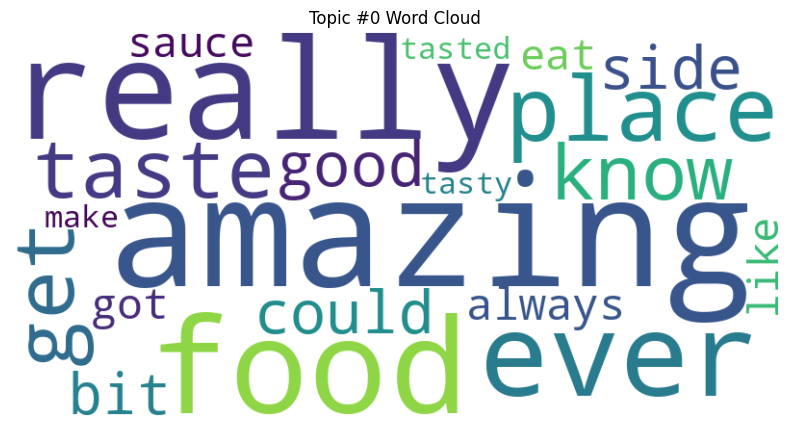

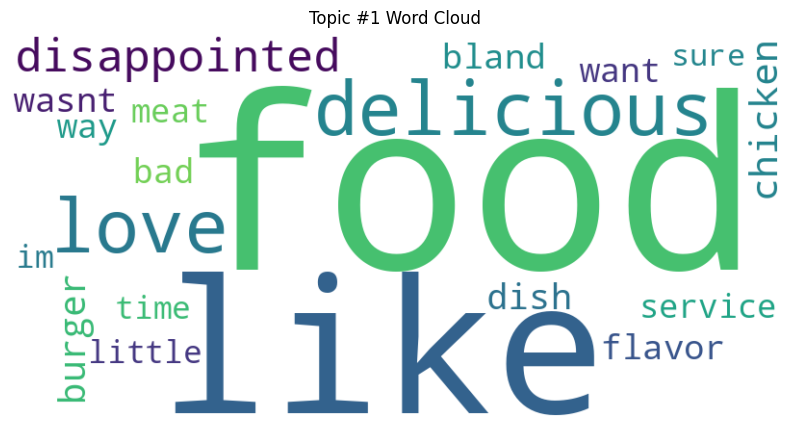

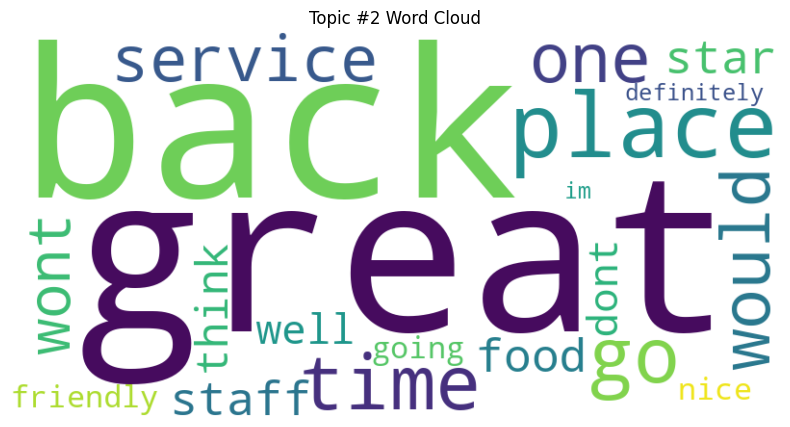

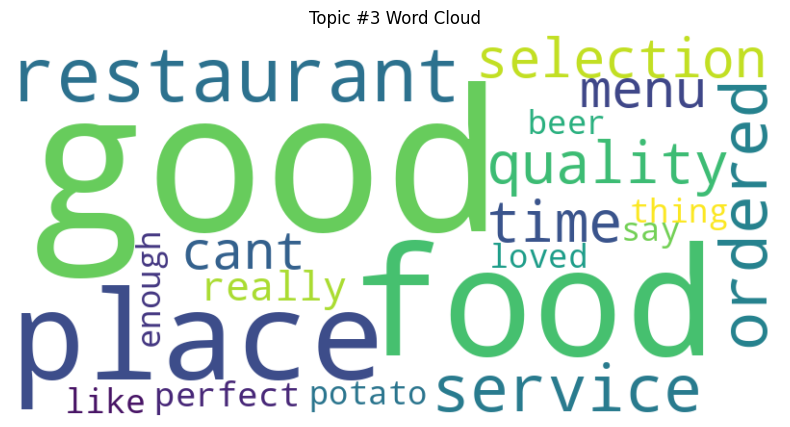

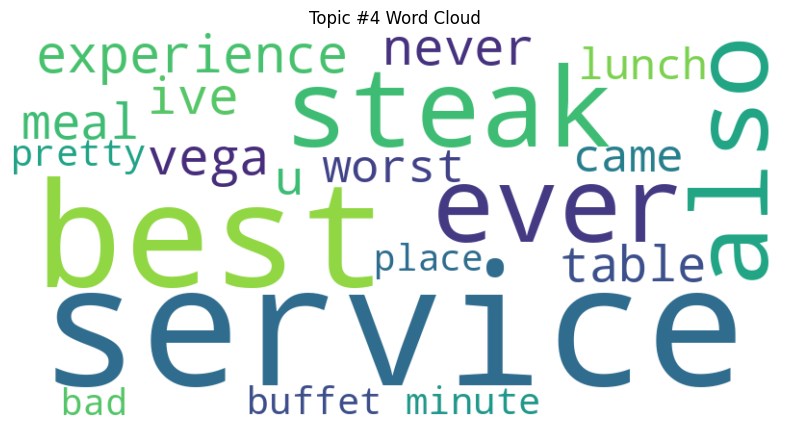


Sentiment Distribution by Topic (Percentages):


Sentiment,Negative,Neutral,Positive
Dominant_Topic,,,
0,25.654450,24.607330,49.738220
1,30.681818,23.295455,46.022727
2,18.800000,29.200000,52.000000
3,24.019608,16.176471,59.803922
4,31.284916,25.139665,43.575419


In [13]:
!pip install wordcloud
!pip install vaderSentiment
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pandas as pd
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# --- Ensure 'cleaned_review' is available ---
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'[\.,!\?:;]', '', text)
    return text
df['cleaned_review'] = df['Review'].apply(preprocess_text)

# --- Ensure 'sentiment_score' and 'sentiment_category' are available ---
analyzer = SentimentIntensityAnalyzer()

def get_sentiment_score(text):
    vs = analyzer.polarity_scores(text)
    return vs['compound']

def categorize_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_score'] = df['cleaned_review'].apply(get_sentiment_score)
df['sentiment_category'] = df['sentiment_score'].apply(categorize_sentiment)

# --- Original code continues below ---

# 1. Print the topics and top 10 words in the topic
print("Topics and their top words:")
for idx, topic in lda_model.print_topics(num_words=10):
    print(f"Topic #{idx}: {topic}")
print("\n")

# Function to get the dominant topic for each document
def get_dominant_topic(ldamodel, corpus, texts):
    # Init output
    sent_topics_df = pd.DataFrame()

    # Get main topic in each document
    for i, corp in enumerate(corpus):
        topic_percs = ldamodel.get_document_topics(corp)
        best_topic = sorted(topic_percs, key=lambda x: x[1], reverse=True)[0]
        wp = ldamodel.show_topic(best_topic[0])
        topic_keywords = ", ".join([word for word, prop in wp])
        sent_topics_df = pd.concat([sent_topics_df, pd.DataFrame([{'Dominant_Topic': int(best_topic[0]),
                                                                'Topic_Perc_Contrib': round(best_topic[1],4),
                                                                'Keywords': topic_keywords}])], ignore_index=True)
    contents = pd.Series(texts)
    sent_topics_df = pd.concat([sent_topics_df, contents], axis=1)
    return(sent_topics_df)

df_topic_sents_keywords = get_dominant_topic(lda_model, corpus, df['processed_review'])

# Add the original 'Liked' and 'sentiment_category' columns to this DataFrame for analysis
df_topic_sents_keywords = pd.concat([df_topic_sents_keywords, df['Liked'], df['sentiment_category']], axis=1)

# Format
df_dominant_topic = df_topic_sents_keywords.reset_index()
df_dominant_topic.columns = ['Document_No', 'Dominant_Topic', 'Topic_Perc_Contrib', 'Keywords', 'Text', 'Liked', 'Sentiment']

# 2. Calculate the frequency of each topic
topic_counts = df_dominant_topic['Dominant_Topic'].value_counts().sort_index()
topic_percentages = df_dominant_topic['Dominant_Topic'].value_counts(normalize=True).sort_index() * 100

print("\nTopic Frequencies:")
for topic_id in topic_counts.index:
    print(f"Topic #{topic_id}: Count = {topic_counts[topic_id]}, Percentage = {topic_percentages[topic_id]:.2f}%")

# 3. Attempt at least one visual display of the topics, such as a word cloud
# Generate word clouds for each topic
for i, topic in lda_model.show_topics(formatted=False, num_words=20):
    wc = WordCloud(background_color="white", max_words=20, width=800, height=400,
                   collocations=False, contour_color='#023075').generate_from_frequencies(dict(topic))
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Topic #{i} Word Cloud")
    plt.show()


# 4. Summarize the sentiment by topic
sentiment_by_topic = df_dominant_topic.groupby(['Dominant_Topic', 'Sentiment']).size().unstack(fill_value=0)
sentiment_by_topic_percentage = sentiment_by_topic.apply(lambda x: x / x.sum() * 100, axis=1)

print("\nSentiment Distribution by Topic (Percentages):")
display(sentiment_by_topic_percentage)

### ✍️ Your Response: 🔧
List your topics and names here:
Amazing Taste, Food Quality, Overall Experience, Restaurant Features, Excellent Service.

## 8. Reflect and Recommend

**Business framing:**  
Ultimately, the value of your model comes from how well it can guide business decisions. Use your results to make real-world recommendations.

### In Your Response:
1. What business question did your model help answer?
2. What would you recommend to this restaurant to improve customer satisfaction?
3. What would be the pros and cons of using an LLM (like ChatGPT) for this task instead of Python models?
4. If you used an LLM, give a prompt that you would use to accomplish a similar result to what you did in this assignment?  (remember to set the context, specify the output and explain the objectives)


✍️ Your Response: 🔧
1. This model was helpful for analyzing 'what customers are talking about in the restaurant review?'
2. I would like to recommend to consistancy of food and service improvement, since lots of reviews mention about it.
3. By using LLM would better for understand the paragraph and customer's thought, and translate it, while it is hard for analyzing in consistency, and need to construct the prompt well, not for making the path to the failure.
4. I will create the prompt like 'You are the restaurant owner. Analyze data and find top 5 key elements customers use. Analyze the rate of 'like' and 'dislike', and find the sentence which include advice. Base on that, analyze what we need to do and give the example for solving.'

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [14]:
!jupyter nbconvert --to html "assignment_13_text_analytics.ipynb"

[NbConvertApp] Converting notebook assignment_13_text_analytics.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 1246003 bytes to assignment_13_text_analytics.html
